In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from sympy import symbols, solve, I


In [ ]:
from matplotlib import cm
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks
from scipy.linalg import eigh
from scipy import integrate 
from scipy.optimize import brentq
import math
from typing import Callable

In [ ]:
# __all__ = ["get_root", ""]


def get_root(func: Callable, a: float, b: float, tol: float=1e-5, max_iter: int=1000) -> float:
	r"""
	Parameters
	----------------
	func : callable
			function f
	a : float 
			lower limit
	b : float
			upper limit
	tol : float
			interval tolerance

	Assuming function $f$ is continuous on the interval $[a,b]$ and that $f(a)$ and $f(b)$ have
	opposite signs (i.e., $f(a)\times f(b) < 0$). The algorithm repeatedly bisects the interval 
	and selects a subinterval where the sign change occurs, effectively narrowing down the range
	where the root must lie. Proceeds as follows:
	1. Compute midpoint $c$ of interval $[a,b]$
	2. Evaluate function $f$ at $c$
	3. Determine which half-interval contains the root based on the sign of $f(c)$ (i.e., if 
	$f(a) \times f(c) < 0$, the root is in $[a,c]$; otherwise in $[c,b]$)
	4. Repeat until interval size < tolerance
	"""
	if func(a) * func(b) >= 0:
			raise ValueError("f(a) and f(b) must have opposite signs")
	
	for _ in range(max_iter):
			c = (a + b) / 2
			fc = func(c)
			
			if fc == 0 or (b - a) / 2 < tol:
					return c
			
			if (func(a) * fc) < 0:
					b = c
			else:
					a = c

	return c

def loss(z, z_0=8):
	"""
	"""
	return np.abs(np.tan(z) - np.sqrt((z_0 / z) ** 2 - 1))


def energy_eigenvalues(z, z_0=8., V_0=1.):
	r"""
	z = z_0\sqrt{\frac{E+V_0}{V_0}}
	-> 
	E = (\frac{z^2}{z_0} - 1)V_0
	"""
	return ((z/z_0)**2 - 1) * V_0

/var/folders/fr/n59gclp95830bd9kqj0dy7hr0000gn/T/ipykernel_10038/2847323879.py:47: RuntimeWarning: divide by zero encountered in divide
  return np.abs(np.tan(z) - np.sqrt((z_0 / z) ** 2 - 1))


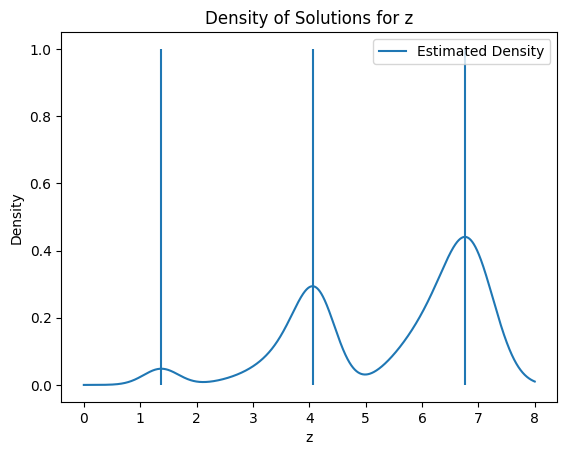

In [3]:
zs = np.linspace(0, 8, 10000)
diffs = loss(zs)
args = np.argsort(diffs)
# print(zs[args])

dz = zs[1] - zs[0]
dloss_dz = np.gradient(np.exp(-diffs), dz)
epsilon = 1e-10


# weights = np.exp(-diffs)/(np.abs(dloss_dz) + epsilon)
weights = np.exp(-diffs)
weights /= np.sum(weights)

kde = gaussian_kde(zs, weights = weights)
densities = kde(zs)

peaks, _ = find_peaks(densities)
# plt.plot(zs[peaks], densities[peaks], "x", label="Peaks")
plt.plot(zs, densities, label='Estimated Density')
plt.vlines(zs[peaks], ymin=0, ymax=1)
plt.xlabel("z")
plt.ylabel("Density")
plt.title("Density of Solutions for z")
plt.legend()
plt.show()

In [4]:
z_calc = zs[peaks]
z_real = np.array([1.3955, 4.165, 6.8306])

print(np.linalg.norm(z_calc - z_real))
E_calc = energy_eigenvalues(z_calc)
E_real = energy_eigenvalues(z_real)
print(np.linalg.norm(E_calc - E_real))

0.12909412854025493
0.020132456064991214


/var/folders/fr/n59gclp95830bd9kqj0dy7hr0000gn/T/ipykernel_10038/1265003486.py:29: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  V[m-1, n-1] = -V0 * np.trapz(integrand, x=xgrid)


Variational method (Rayleigh–Ritz) results:
Found bound state energies (in our units):
[np.float64(-0.9621023389674193), np.float64(-0.8491321604498175), np.float64(-0.6639083421133691), np.float64(-0.4128051945003369), np.float64(-0.11739934113097161)]
State 1: E = -0.9621023389674193
State 2: E = -0.8491321604498175
State 3: E = -0.6639083421133691


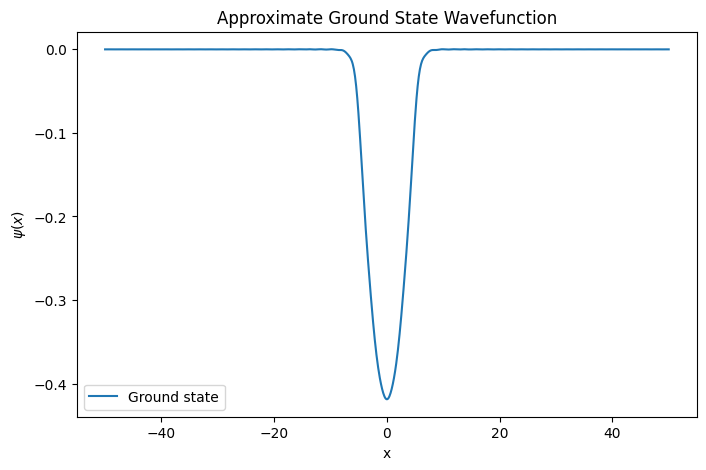

In [6]:
# Parameters in our units: ħ = m = a = 1.
a    = 5.0        # half-width of the well (|x|<a)
V0   = 1.0        # well depth
L    = 50.0         # half-length of the domain; choose L >> a so that ψ(~±L) ~ 0
N    = 100          # number of basis functions to use


def phi(n, x, L):
    """Basis function phi_n(x) for n=1,2,... defined on [-L, L]."""
    return np.sqrt(1.0/L) * np.sin(n * np.pi * (x + L) / (2*L))


# Kinetic energy operatior T = -1/2 d^2/dx^2
T = np.zeros((N, N))

for n in range(1, N+1):
    T[n-1, n-1] = 0.5 * (n * np.pi / (2 * L))**2

# Create a fine grid over the region where the potential is nonzero.
xgrid = np.linspace(-a, a, 500)
dx = xgrid[1] - xgrid[0]

# Potential energy operator
V = np.zeros((N, N))

for m in range(1, N+1):
    for n in range(1, N+1):
        integrand = phi(m, xgrid, L) * phi(n, xgrid, L)
        V[m-1, n-1] = -V0 * np.trapz(integrand, x=xgrid)

# Full Hamiltonian
H = T + V

eigvals, eigvecs = eigh(H)

# Bound states have E < 0.
bound_eigvals = [e for e in eigvals if e < 0]

print("Variational method (Rayleigh–Ritz) results:")
print("Found bound state energies (in our units):")
print(bound_eigvals)
for i, E in enumerate(bound_eigvals[:3], 1):
    print(f"State {i}: E = {E}")

# (Optional) Plot the ground state wavefunction in our basis representation.
# Reconstruct the approximate wavefunction from the basis.
xplot = np.linspace(-L, L, 1000)
psi_ground = np.zeros_like(xplot)
ground_state = eigvecs[:, np.argmin(eigvals)]  # eigenvector corresponding to lowest energy
for n in range(1, N+1):
    psi_ground += ground_state[n-1] * phi(n, xplot, L)

plt.figure(figsize=(8,5))
plt.plot(xplot, psi_ground, label="Ground state")
plt.xlabel("x")
plt.ylabel(r"$\psi(x)$")
plt.title("Approximate Ground State Wavefunction")
plt.legend()
plt.show()

In [ ]:

# Parameters in units: ħ = 1, m = 1, a = 1.
a    = 1.0
m    = 1.0
hbar = 1.0
V0   = 10.0  # chosen so that 2mV0a^2/ħ^2 = 20, which supports 3 bound states

# Calculate z0:
z0 = a * np.sqrt(2 * m * V0 / hbar**2)
print("z0 =", z0)

# Define the transcendental functions for even and odd states.
# Even states: f_even(z) = z tan(z) - sqrt(z0^2 - z^2) = 0.
def f_even(z):
    return z * np.tan(z) - np.sqrt(z0**2 - z**2)

# Odd states: f_odd(z) = -z cot(z) - sqrt(z0^2 - z^2) = 0.
# (cot(z) = 1/tan(z))
def f_odd(z):
    return -z / np.tan(z) - np.sqrt(z0**2 - z**2)

# Find roots:
# Even state 1: Look in the interval (0, π/2)
z_even1 = brentq(f_even, 0.001, np.pi/2 - 0.001)

# Odd state 1: Look in the interval (π/2, π)
z_odd1 = brentq(f_odd, np.pi/2 + 0.001, np.pi - 0.001)

# Even state 2: Look in the interval (π, z0).
# (We must check that a sign change occurs.)
try:
    z_even2 = brentq(f_even, np.pi + 0.001, z0 - 0.001)
except ValueError:
    z_even2 = None

print("\nFound z values (in radians):")
print("Even state 1: z =", z_even1)
print("Odd state 1:  z =", z_odd1)
if z_even2 is not None:
    print("Even state 2: z =", z_even2)
else:
    print("Even state 2: No solution found in (π, z0)")

# Convert z to energy using: E = -V0 + (ħ^2 * z^2)/(2m a^2)
E_even1 = -V0 + (hbar**2 * z_even1**2) / (2 * m * a**2)
E_odd1  = -V0 + (hbar**2 * z_odd1**2)  / (2 * m * a**2)
if z_even2 is not None:
    E_even2 = -V0 + (hbar**2 * z_even2**2) / (2 * m * a**2)
else:
    E_even2 = None

print("\nEnergy eigenvalues (in our units):")
print("Even state 1: E =", E_even1)
print("Odd state 1:  E =", E_odd1)
if E_even2 is not None:
    print("Even state 2: E =", E_even2)


In [ ]:
import numpy as np
import scipy.integrate as integrate
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Constants (again, arbitrary units)
hbar = 1.0
m = 1.0
V0 = 50.0
a = 1.0

# The normalized Gaussian trial wavefunction:``
# psi(x;alpha) = (2*alpha/pi)^(1/4) exp(-alpha x^2)
def psi(x, alpha):
    A = (2*alpha/np.pi)**0.25
    return A * np.exp(-alpha * x**2)

# Kinetic energy expectation value for this trial function
def kinetic_energy(alpha):
    # For a Gaussian, one can show <T> = (hbar^2 alpha)/(2m)
    return hbar**2 * alpha / (2*m)

# Potential energy: V(x) = -V0 for |x| <= a, 0 for |x| > a.
def potential_energy(alpha):
    integrand = lambda x: psi(x, alpha)**2
    # Integrate over the region where V(x) = -V0 (i.e. inside the well)
    prob_inside, _ = integrate.quad(integrand, -a, a)
    return -V0 * prob_inside

# Total energy expectation value
def total_energy(alpha):
    return kinetic_energy(alpha) + potential_energy(alpha)

# Evaluate the energy as a function of alpha
alphas = np.linspace(0.1, 10, 200)
energies = [total_energy(alpha) for alpha in alphas]

plt.plot(alphas, energies)
plt.xlabel('alpha')
plt.ylabel('Energy')
plt.title('Variational Energy using Gaussian Trial Function')
plt.show()

# Minimize the energy with respect to alpha
res = minimize(lambda x: total_energy(x[0]), x0=[1.0], bounds=[(0.01, None)])
alpha_opt = res.x[0]
E_opt = total_energy(alpha_opt)
print("Optimal alpha:", alpha_opt)
print("Variational Energy:", E_opt)

In [ ]:
# Parameters (in arbitrary units)
hbar = 1.0         # Planck's constant
m = 1.0            # Particle mass
a = 1.0            # Half-width of the well
# Choose V0 so that 2mV0a^2/ħ^2 = 8  => V0 = 8*ħ^2/(2*m*a^2) = 4 (if hbar=m=a=1)
V0 = 4.0

# Spatial grid: choose a domain large enough so that the bound states vanish at the edges.
L = 5.0*a         # domain extends from -L to L
N = 1000          # number of grid points
x = np.linspace(-L, L, N)
dx = x[1] - x[0]

# Construct the kinetic energy operator using the finite-difference method.
# Second derivative (central difference):
diag = -2.0 * np.ones(N)
offdiag = 1.0 * np.ones(N-1)
laplacian = (np.diag(diag) + np.diag(offdiag, 1) + np.diag(offdiag, -1)) / (dx**2)
T = - (hbar**2 / (2*m)) * laplacian

# Construct the potential energy operator:
V = np.zeros(N)
for i in range(N):
    if np.abs(x[i]) < a:
        V[i] = -V0
    else:
        V[i] = 0.0
V_matrix = np.diag(V)

# The full Hamiltonian is:
H = T + V_matrix

# Solve the eigenvalue problem
eigenvalues, eigenvectors = eigh(H)

# Extract bound state eigenvalues (E < 0)
bound_indices = np.where(eigenvalues < 0)[0]
bound_eigenvalues = eigenvalues[bound_indices]

print("Bound state energies (variational upper bounds):")
for E in bound_eigenvalues:
    print(E)

# (Optional) Plot the lowest bound eigenstate
plt.figure(figsize=(8,5))
plt.plot(x, eigenvectors[:, bound_indices[0]], label='Ground state')
plt.xlabel('x')
plt.ylabel(r'$\psi(x)$')
plt.title('Lowest bound eigenstate')
plt.legend()
plt.show()


In [ ]:
# Constants (in arbitrary units)
hbar = 1.0
m = 1.0
V0 = 1.0   # Depth of the well
a = 1.0     # Half-width of the well

# Set up the spatial grid
x_min = -5.0
x_max = 5.0
N = 1000            # Number of grid points
x = np.linspace(x_min, x_max, N)
dx = x[1] - x[0]

# Define the finite square well potential:
# V(x) = -V0 for |x| <= a, and 0 for |x| > a.
V = np.zeros_like(x)
V[np.abs(x) <= a] = -V0
V[np.abs(x) > a] = 0

# Construct the kinetic energy matrix using finite differences:
# Here we use the standard second-derivative approximation.
T = np.zeros((N, N))
coeff = hbar**2 / (2 * m * dx**2)
for i in range(N):
    T[i, i] = 2 * coeff
    if i > 0:
        T[i, i-1] = -coeff
    if i < N-1:
        T[i, i+1] = -coeff



# The Hamiltonian matrix is H = T + V (with V added along the diagonal)
H = T + np.diag(V)

# Diagonalize the Hamiltonian
eigvals, eigvecs = eigh(H)

print("Lowest 5 eigenvalues (energy levels):")
print(eigvals[:5])

# Plot the ground-state wavefunction
ground_state = eigvecs[:, 0]
plt.plot(x, ground_state, label='Ground State')
plt.xlabel('x')
plt.ylabel('psi(x)')
plt.title('Ground State Wavefunction for the Finite Square Well')
plt.legend()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define symbols
x, t1, t2 = sp.symbols('x t1 t2')

# Define the polynomial
polynomial: sp.Symbol = 4*x**3 + (1-t1**2)*x - sp.I*t2**3 - sp.I

# Function to compute the roots for given t1 and t2
def compute_roots(t1_val, t2_val):
	poly_sub = polynomial.subs({t1: t1_val, t2: t2_val})
	roots = sp.solve(poly_sub, x)
	return [complex(root.evalf()) for root in roots]

# Define unit circle parameters
num_points = 100
angles = np.linspace(0, 2*np.pi, num_points)
t1_values = np.exp(1j * angles)  # t1 on unit circle
t2_values = np.exp(1j * angles)  # t2 on unit circle
t_vals1, t_vals2  = np.meshgrid(t1_values, t2_values)
t_vals = np.stack([t_vals1.flatten(), t_vals2.flatten()], axis=-1)

# Plot setup
plt.figure(figsize=(10, 8))

# Loop over values of t1 and t2 and plot the roots
roots_list = []
for t1, t2 in t_vals:
	roots = compute_roots(t1, t2)
	for root in roots:
		roots_list.append(np.array([root.real, root.imag]))

# Customize plot
plt.plot(*np.array(roots_list).T, 'bo', markersize=2)
plt.axhline(0, color='gray', lw=0.5)
plt.axvline(0, color='gray', lw=0.5)
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.title('Roots of Parametric Polynomial $4x^3+ (1-t_1^2)x - it_2^3-i$')
plt.grid(True)
plt.show()


AttributeError: 'Add' object has no attribute 'real'

<Figure size 1000x800 with 0 Axes>